In [48]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from GraphDatAll import GraphDataset
torch.manual_seed(42)

In [49]:
class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        # self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='target_to_source', root_weight=False)
        # self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='target_to_source', root_weight=False)
        # self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='target_to_source', root_weight=False)
        self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='source_to_target', root_weight=False)
        self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='source_to_target', root_weight=False)
        self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='source_to_target', root_weight=False)
        self.lin1 = nn.Linear(hidden_channels, int(hidden_channels/2))
        self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = F.dropout(F.relu(self.lin1(x)), p=0.2)
        x = self.lin2(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # x = self.sm(x)
        return x

In [50]:
def round_function(x, d):
    new = []
    for r in x:
        new.append(np.round(r,decimals=d))
    # pdb.set_trace()
    return tuple(new)

In [51]:
# Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
def loss_function(reconstructed_x, original_x):
    # weights = torch.tensor([  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238], dtype=torch.float)
    total = 1.0#2204689.0
    # arr = [1410221,  794468] 
    arr = [1.0, 1.0]
    weights = torch.tensor([total/a for a in arr], dtype = torch.float)
    
    weights = weights/torch.sum(weights)
    # return F.cross_entropy(reconstructed_x, original_x, weight=weights, label_smoothing=0.2)
    # return F.cross_entropy(reconstructed_x, original_x, label_smoothing=0.4)
    return F.cross_entropy(reconstructed_x, original_x, weight=weights)
    # return F.cross_entropy(reconstructed_x, original_x)#/scale#, label_smoothing=0.4)   

In [52]:
def train(model, dataloader, optimizer, device):#, timeclasses):
    
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    qs = []
    agents = []
    printlosses = []
    for feat, edge, _, succ, q, nA in dataloader:
        optimizer.zero_grad()
        features = feat.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        embed = model(features, edges)
        
        qs.append(q)
        agents.append(nA)

        # time_classes = times.squeeze_(0).to(device)
        loss = loss_function(embed, succ.squeeze_(0).to(device)) #cosine_loss(data[1][0].to(device), embed)
        origs.append(succ.detach())
        # loss = cosine_loss(embed, classes) 
        # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.detach().item()
        printlosses.append(loss.detach().item())
        if len(printlosses)%1000 == 0:
            printlosses = printlosses[-1000:]
            print(np.sum(printlosses)/1000.0)
        embeddings.append(embed.detach())
        # print(total_loss)/10.0
    return total_loss / len(dataloader), embeddings, origs, qs, agents

In [53]:
folder_graph = './'
device = "cpu"
# fname = 'small_graphs.pth'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
# files = ['alledges', 'allsucc', 'alltime', 'edgesList', 'nodeIDs']
hC = 20
inC = 40
outchannels = 2

In [54]:


# dataset = GraphDataset(folder_graph, files)
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
fg = './finished_with_labels/'
files = os.listdir(fg)
files = [file for file in files if file.endswith('.pickle')]
dataset = GraphDataset(fg, files)#, meta)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)

# dataloader=
# dataloader = [torch.tensor(times_, dtype=torch.long).to(device), torch.tensor(nodesList, dtype=torch.float).to(device), torch.tensor(edges, dtype=torch.long).t().to(device)]
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.1)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
losses = []
embeds = []
acts = []
# timeclasses = torch.tensor(times_, dtype=torch.long).to(device)

In [55]:


for epoch in range(1, 5):  # Number of epochs
    loss, _, _, _, _ = train(model, dataloader, optimizer, device)#, timeClasses)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)
model.eval()
# Assuming encoder and decoder are your model's components
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, str(hC) +'ALLSucc_encoder_state_dict'+str(outchannels)+'.pth')
# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 5):  # Number of epochs
    loss, _, _, _, _ = train(model, dataloader, optimizer, device)#, timeClasses)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, str(hC) +'ALLSucc_encoder_state_dict'+str(outchannels)+'.pth')


0.5750142891803917
0.512508136514829
0.49134144706008376
0.48742159628268567
Epoch 1, Loss: 0.5153
0.48264615654863885
0.44893994045228464
0.46567219231760826
0.4530571130227181
Epoch 2, Loss: 0.4635
0.45523865239683076
0.43666018786863425
0.45189036782865877
0.4476579632899957
Epoch 3, Loss: 0.4510
0.457803153090179
0.4454858453928027
0.4449170417312998
0.44089417870691977
Epoch 4, Loss: 0.4483


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
embeds = []
acts = []
qarr = []
agarr = []
for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig, qs, agents = train(model, dataloader, optimizer, device)#, timeClasses)
    embeds.append(embed)
    acts.append(orig)
    agarr.append(agents)
    qarr.append(qs)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, str(hC) +'ALLSucc_encoder_state_dict'+str(outchannels)+'.pth')

fl = open(str(hC) + 'succall_classresults_3_5.pickle', 'wb')
pickle.dump(embeds, fl)
fl.close()

fl = open(str(hC) + 'succall_classactuals_3_5.pickle', 'wb')
pickle.dump(acts, fl)
fl.close()

fl = open(str(hC) + 'succall_classquals_3_5.pickle', 'wb')
pickle.dump(qarr, fl)
fl.close()

fl = open(str(hC) + 'succall_classagents_3_5.pickle', 'wb')
pickle.dump(agarr, fl)
fl.close()


0.40988860234292224
0.42117110983561723
0.4082288534832187
0.4329204892339185
Epoch 1, Loss: 0.4193
0.42074695285316555
0.4232718681371771
0.41232044251356276
0.4227897354327142
Epoch 2, Loss: 0.4197


In [ ]:

# fil2 = open('MULTIPLEalltime.pickle', 'rb')
# times = pickle.load(fil2)
# fil2.close()

# fil2 = open('allsucc.pickle', 'rb')
# successes = pickle.load(fil2)
# fil2.close()

# fil2 = open('edgeList.pickle', 'rb')
# edges = pickle.load(fil2)
# fil2.close()

# fil2 = open('nodeIDs.pickle', 'rb')
# nodes = pickle.load(fil2)
# fil2.close()

# meanTimes = dict()
# for n in times:
#     meanTimes[n] = np.mean(times[n])
# TIME_LIMIT =  400

# def round_function(x, d):
#     new = []
#     for r in x:
#         new.append(np.round(r,decimals=d))
#     # pdb.set_trace()
#     return tuple(new)

# def get_class(a):
#     if a > TIME_LIMIT:
#         return 0
#         retVal = torch.tensor(0, dtype=torch.long)
#         return retVal
#     else:
#         return 1
#         retVal = torch.tensor(1, dtype=torch.long)
#         return retVal
    # arr = []
    # if a > TIME_LIMIT:
    #     arr.append(0)
    # else:
    #     arr.append(1)

    # try:
    #     retVal = torch.tensor(arr, dtype=torch.long)
    #     return retVal
    # except:
    #     pdb.set_trace()
    # edges
# timeClasses = dict()
# for n in meanTimes:
#     timeClasses[n] = get_class(meanTimes[n])

# times_ = []
# for t in timeClasses.values():
#     times_.append(t)


# nodesList = []
# for n in nodes:
#     nodesList.append(n)


In [ ]:
# optimizer = optim.Adam(model.parameters(), lr=0.0001)

# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)
# model.eval()
# encoder_state_dict = model.state_dict()
# torch.save(encoder_state_dict, './ALLTime_encoder_state_dict'+str(outchannels)+'.pth')

In [ ]:
# GAE = GraphEncoderWithResidual(inC, hC, outchannels)
# import pickle
# import numpy as np
# import torch


# from collections import defaultdict 

# encoder_dict = torch.load('./ALLTime_encoder_state_dict2.pth')


In [ ]:

# GAE = GraphEncoderWithResidual(inC, hC, outchannels)
# GAE.load_state_dict(encoder_dict)
# emb = []
# arrtosave = []

In [ ]:
# print(np.shape(torch.tensor([nodesList[0]], dtype=torch.float)), np.shape(torch.tensor([[],[]], dtype=torch.long)))
# GAE(torch.tensor([nodesList[0]], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long))


In [ ]:

# # for i in arr1: 
# GAE.eval()
# emb = []
# for ii in nodesList: 
#     # break
# # GAE(torch.tensor([ast.literal_eval(i)], dtype=torch.float), torch.empty((2,0), dtype=torch.int64).detach().tolist()[0])
#     try:
#         # pdb.set_trace()
#         emb.append(GAE(torch.tensor([ii], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long)).detach().tolist()[0])
#         # arrtosave.append(i) 
#     except Exception as e:
#         print(e)
#         print(np.shape(ii))

In [ ]:
# times_
# times_check = []
# for t in times_:
#     times_check.append(t.tolist())

In [ ]:
# import numpy as np
# from scipy.special import expit, logit
# emb
# newembs = []
# for e in emb:
#     newembs.append(expit(e))

# newembs
# emb

In [ ]:
# print(np.shape(times_check), np.shape(emb))

# y_true_indices = times_check#np.argmax(times_check, axis=1)
# y_pred_indices = np.argmax(emb, axis=1)
# # print(np.argmax(emb, axis=1)[0:10])
# # print(np.argmax(arrclass, axis=1)[0:10])
# loss, embed, orig, qs, agents = train(model, dataloader, optimizer, device)#, timeClasses)
# embeds.append(embed)
# acts.append(orig)
# agarr.append(agents)
# qarr.append(qs)
# print(np.shape(embeds[0]))
# print(embeds)
# print(np.shape(acts))
y_true_indices = []
y_pred_indices = []
outs = []
counter = 0
for ee, oo, qq in zip(embeds, acts, qarr):
    counter +=1
    # print(np.shape(ee), np.shape(oo))
    for id, (e, o, q) in enumerate(zip(ee, oo, qq)):
        outs+=e.tolist()
        y_true_indices+=list(o)
        y_pred_indices+=np.argmax(e, axis=1)
        # break
    # break
# print(y_true_indices, y_pred_indices)


In [ ]:
out = np.array(outs)
# print(np.shape(out[:,0]))
cols = []
for i in y_true_indices:
    if i == 0:
        cols.append([1,0,0])
    else:
        cols.append([0,1,0])


(1353174,) (1353174,)


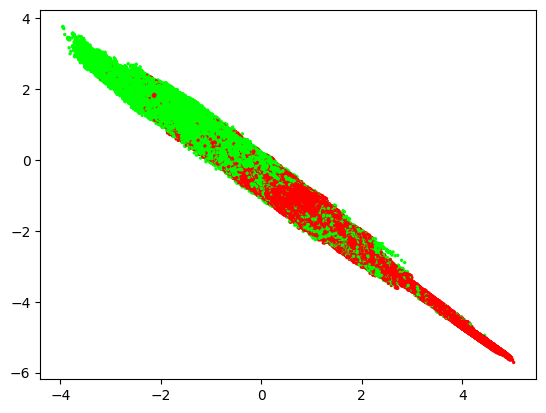

In [ ]:
print(np.shape(y_true_indices), np.shape(y_pred_indices))
# colors = ['r','g']

plt.scatter(out[:,0], out[:,1], c=cols, s=2)


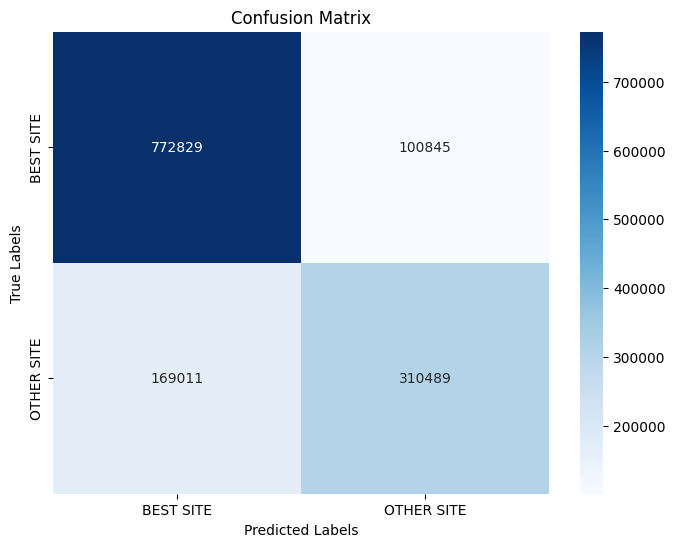

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns


cm = confusion_matrix(y_true_indices, y_pred_indices)
# ConfusionMatrixDisplay(cm).plot()
# CLIST =  ["Fast/Failure", "Slow/Failure", "Fast/Success", "Slow/Success"]

CLIST =  ["SLOW", "FAST"]
CLIST= ["BEST SITE", "OTHER SITE"]
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# 

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

In [ ]:
print('roc auc score: ', roc_auc_score(y_true_indices, y_pred_indices))
print('precision score: ', precision_score(y_true_indices, y_pred_indices))
print('recall score: ', recall_score(y_true_indices, y_pred_indices))
print('f1 score: ', f1_score(y_true_indices, y_pred_indices))
print('accuracy score: ', accuracy_score(y_true_indices, y_pred_indices))


roc auc score:  0.7660501206197936
precision score:  0.7548342709331103
recall score:  0.6475265901981231
f1 score:  0.6970748759028057
accuracy score:  0.8005755357404147


10:

roc auc score:  0.7847262434011781
precision score:  0.7394655295706757
recall score:  0.7593559617058312
f1 score:  0.7492787655149278
accuracy score:  0.7890321560834613

5: 

roc auc score:  0.7807121435124047
precision score:  0.7352067868504772
recall score:  0.7542428198433421
f1 score:  0.7446031575555795
accuracy score:  0.7852045885647186

In [ ]:


# print(np.sum([1 for y in y_true_indices if y == 1]))
# total = np.sum(cm, axis=1)
# print(total, np.sum(total))
# print(cm)
# 0: 14022, 1: 35079, 2: 780448 1375238

In [ ]:
# import torch
# import statistics
# arr = []
# for a in meta:
#     arr.append(statistics.mean(meta[a]))

# times_ = []
# for t in timeClasses.values():
#     times_.append(t)
# # print(n)
# import matplotlib.pyplot as plt
# x=plt.hist(times_)
# plt.xlim([0,200])


# import shutil
# import os
# import numpy as np
# import pandas as pd
# from ast import literal_eval
# from collections import defaultdict
# def other():
#     folder = '../../graphsage_results/CDC/multiple_agent_env_results/'
#     files = os.listdir(folder)
#     files = [file for file in files if file.endswith('.csv') and file.startswith('1')]
#     files = np.sort(files)
#     # data_files = []
#     metadata_file = folder + 'metadata.csv'
#     # folder_graph = './graphs/RS/fast_multiple_graphs/'
#     # new_metadata_file = folder_graph + 'metadata.csv'
#     # graph_metaFile = 'graphMetadata.csv'
#     # meta_arr = []
#     metadata = pd.read_csv(metadata_file) 
#     metadata.site_qualities=metadata.site_qualities.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(lambda x: tuple([tuple(a) for a in x]))
#     metadata.site_qualities=metadata.site_qualities.apply(lambda x: tuple(x))
#     df = metadata.groupby(by=['site_qualities', 'site_positions', 'num_agents'], as_index=False).agg(lambda x: x.tolist())
#     Gtime = defaultdict(list)
#     Gsucc = defaultdict(list)
#     Gedge = defaultdict(defaultdict)
    
#     for some_id, entry in enumerate(df.iterrows()):
#         # copy files
#         for file in entry[1].iloc[3]:
#             shutil.copyfile(folder+file, '../../oneGraphFiles/'+file)
#         break

# other()